# Case study: temporal evolution of attribution graphs

Diffusion runs the same network across denoising steps. We trace one (prompt, image-target) pair - $f^{(img,12)}_{reflection}$ on *"a mountain reflected in a still lake"* - at each of the 4 steps and measure (i) the image- vs text-stream share of attribution mass and (ii) the fraction of cross-modal edges.

Text-stream influence collapses from ~90% at step 0 to ~5% at step 3 - a two-phase trajectory. We then confirm it **causally**: because text features carry their influence at the *early* steps, suppressing a text-stream semantic supernode changes the image only when applied early.

In [1]:
import os

os.environ.setdefault("TRANSCODERS_DIR", "/path/to/transcoders")

from transcoder_circuits.replacement_model import LRMConfig
from transcoder_circuits.circuit_analysis import LRMPipeline

cfg = LRMConfig(target_layers=tuple(range(16)))
pipeline = LRMPipeline(cfg)
pipeline.initialize()
pipeline.load_transcoders()
pipe, transcoders = pipeline.pipe, pipeline.transcoders

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

## 1. Trace the same target at every denoising step

The target is the reflection feature $f^{(img,12)}_{reflection}$ on *"a mountain reflected in a still lake"*. We trace it at each of the 4 steps (the paper aggregates 20 such pairs but one is enough to see the trajectory).

In [2]:
PROMPT = "a mountain reflected in a still lake"
TARGET = {"layer": 12, "stream": "img", "feat_idx": 1023, "prompt": PROMPT, "seed": 42}

for step in range(4):
    pipeline.run_experiment([{**TARGET, "step": step}], output_dir=f"temporal_graphs/step{step}")

  0%|          | 0/4 [00:00<?, ?it/s]

[1/1] L12 img f1023  1054s  pruned 430 nodes / 32381 edges  rel_err 14.46%  spearman 0.733
1 targets processed -> temporal_graphs/step0/experiment_summary.csv


  0%|          | 0/4 [00:00<?, ?it/s]

[1/1] L12 img f1023  1745s  pruned 371 nodes / 16163 edges  rel_err 21.41%  spearman 0.852
1 targets processed -> temporal_graphs/step1/experiment_summary.csv


  0%|          | 0/4 [00:00<?, ?it/s]

[1/1] L12 img f1023  1575s  pruned 396 nodes / 21789 edges  rel_err 21.26%  spearman 0.879
1 targets processed -> temporal_graphs/step2/experiment_summary.csv


  0%|          | 0/4 [00:00<?, ?it/s]

[1/1] L12 img f1023  1440s  pruned 460 nodes / 37559 edges  rel_err 23.91%  spearman 0.712
1 targets processed -> temporal_graphs/step3/experiment_summary.csv


## 2. Read the stream shares and cross-modal edge fraction off the saved graphs

For the saved graph at each step: the image/text **attribution share** is the summed |attribution| of feature-source edges in each stream. The **cross-modal fraction** is the share of edges whose endpoints lie in different streams.

In [3]:
import glob, json
import numpy as np
import matplotlib.pyplot as plt


def graph_stats(path):
    G = json.load(open(path, encoding="utf-8"))
    nodes = {n["id"]: n for n in G["nodes"]}
    img_mass = txt_mass = 0.0
    cross = total = 0
    for e in G["edges"]:
        s, t = nodes.get(e["src"], {}), nodes.get(e["tgt"], {})
        ss, ts = s.get("stream"), t.get("stream")
        if ss and ts:
            total += 1
            if ss != ts:
                cross += 1
        if s.get("type") == "feature":
            if ss == "img":
                img_mass += abs(e["attribution"])
            elif ss == "txt":
                txt_mass += abs(e["attribution"])
    denom = img_mass + txt_mass or 1.0
    return {"img_share": img_mass / denom, "txt_share": txt_mass / denom, "cross_frac": cross / (total or 1)}


img_share, txt_share, cross_frac = [], [], []
for step in range(4):
    stats = [graph_stats(p) for p in glob.glob(f"temporal_graphs/step{step}/*.json")]
    img_share.append(np.mean([s["img_share"] for s in stats]))
    txt_share.append(np.mean([s["txt_share"] for s in stats]))
    cross_frac.append(np.mean([s["cross_frac"] for s in stats]))
    print(f"step {step}: img={img_share[-1]:.1%}  txt={txt_share[-1]:.1%}  cross={cross_frac[-1]:.1%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(range(4), img_share, "o-", label="image stream")
ax1.plot(range(4), txt_share, "s-", label="text stream")
ax1.set_xlabel("denoising step"); ax1.set_ylabel("attribution share"); ax1.legend()
ax2.plot(range(4), cross_frac, "d-", color="purple")
ax2.set_xlabel("denoising step"); ax2.set_ylabel("cross-modal edge fraction")
plt.tight_layout(); plt.show()

step 0: img=2.5%  txt=97.5%  cross=17.5%
step 1: img=45.7%  txt=54.3%  cross=13.3%
step 2: img=74.9%  txt=25.1%  cross=4.4%
step 3: img=96.3%  txt=3.7%  cross=1.0%


## 3. Interactive graph per denoising step

Render the saved graph at each of the 4 steps as an interactive HTML view. Image-stream features sit on the left and text-stream features on the right, so along the trajectory the **right (text) half shrinks while the left (image) half grows**.

In [4]:
import glob
from transcoder_circuits import circuit_visualization as cv

# Image-stream features render on the left and text-stream on the right,
# so across the 4 steps the text (right) half visibly shrinks while
# the image (left) half grows - the same stream shift quantified above.
for step in range(4):
    gpath = sorted(glob.glob(f"temporal_graphs/step{step}/*.json"))[-1]
    G = cv.load_graph(gpath)
    cv.print_graph_stats(G, step)
    cv.build_interactive_graph(G, idx=step, top_edges=1000, output_file=f"temporal_graph_step{step}.html")


Graph [0]: L12 img f1023  | a mountain reflected in a still lake
  step=0  seed=42  rel_err=14.46%
  Nodes: 88 feat-img, 316 feat-txt, 24 error, 2 input  (430 total)
  Edges: 32381 total, 27435 feat, 4383 cross-modal (16.0%)
  Direct attribution to target:
    feat-img: +2.5254 (3.8%)  feat-txt: +29.8250 (44.6%)  error: +29.5709 (44.3%)  input: +4.8885 (7.3%)
Graph[0]: 430 nodes, 32381/32381 edges -> temporal_graph_step0.html

Graph [1]: L12 img f1023  | a mountain reflected in a still lake
  step=1  seed=42  rel_err=21.41%
  Nodes: 260 feat-img, 85 feat-txt, 24 error, 2 input  (371 total)
  Edges: 16163 total, 10243 feat, 664 cross-modal (6.5%)
  Direct attribution to target:
    feat-img: +38.6968 (41.3%)  feat-txt: +4.5102 (4.8%)  error: +36.6326 (39.1%)  input: +13.9194 (14.8%)
Graph[1]: 371 nodes, 16163/16163 edges -> temporal_graph_step1.html

Graph [2]: L12 img f1023  | a mountain reflected in a still lake
  step=2  seed=42  rel_err=21.26%
  Nodes: 328 feat-img, 42 feat-txt, 24

## 4. Causal check: stepwise suppression

Text features carry their influence at the early steps, so suppressing one at steps {0,1} changes the image while suppressing it at {2,3} does not. Following the paper, we suppress the text-stream *cat* supernode on *"a cat sitting on a red couch"* at early vs late steps.

cat_early_0_1: 3 seeds | 'a cat sitting on a red couch'
    seed 0 (1/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

    seed 1 (2/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

    seed 2 (3/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

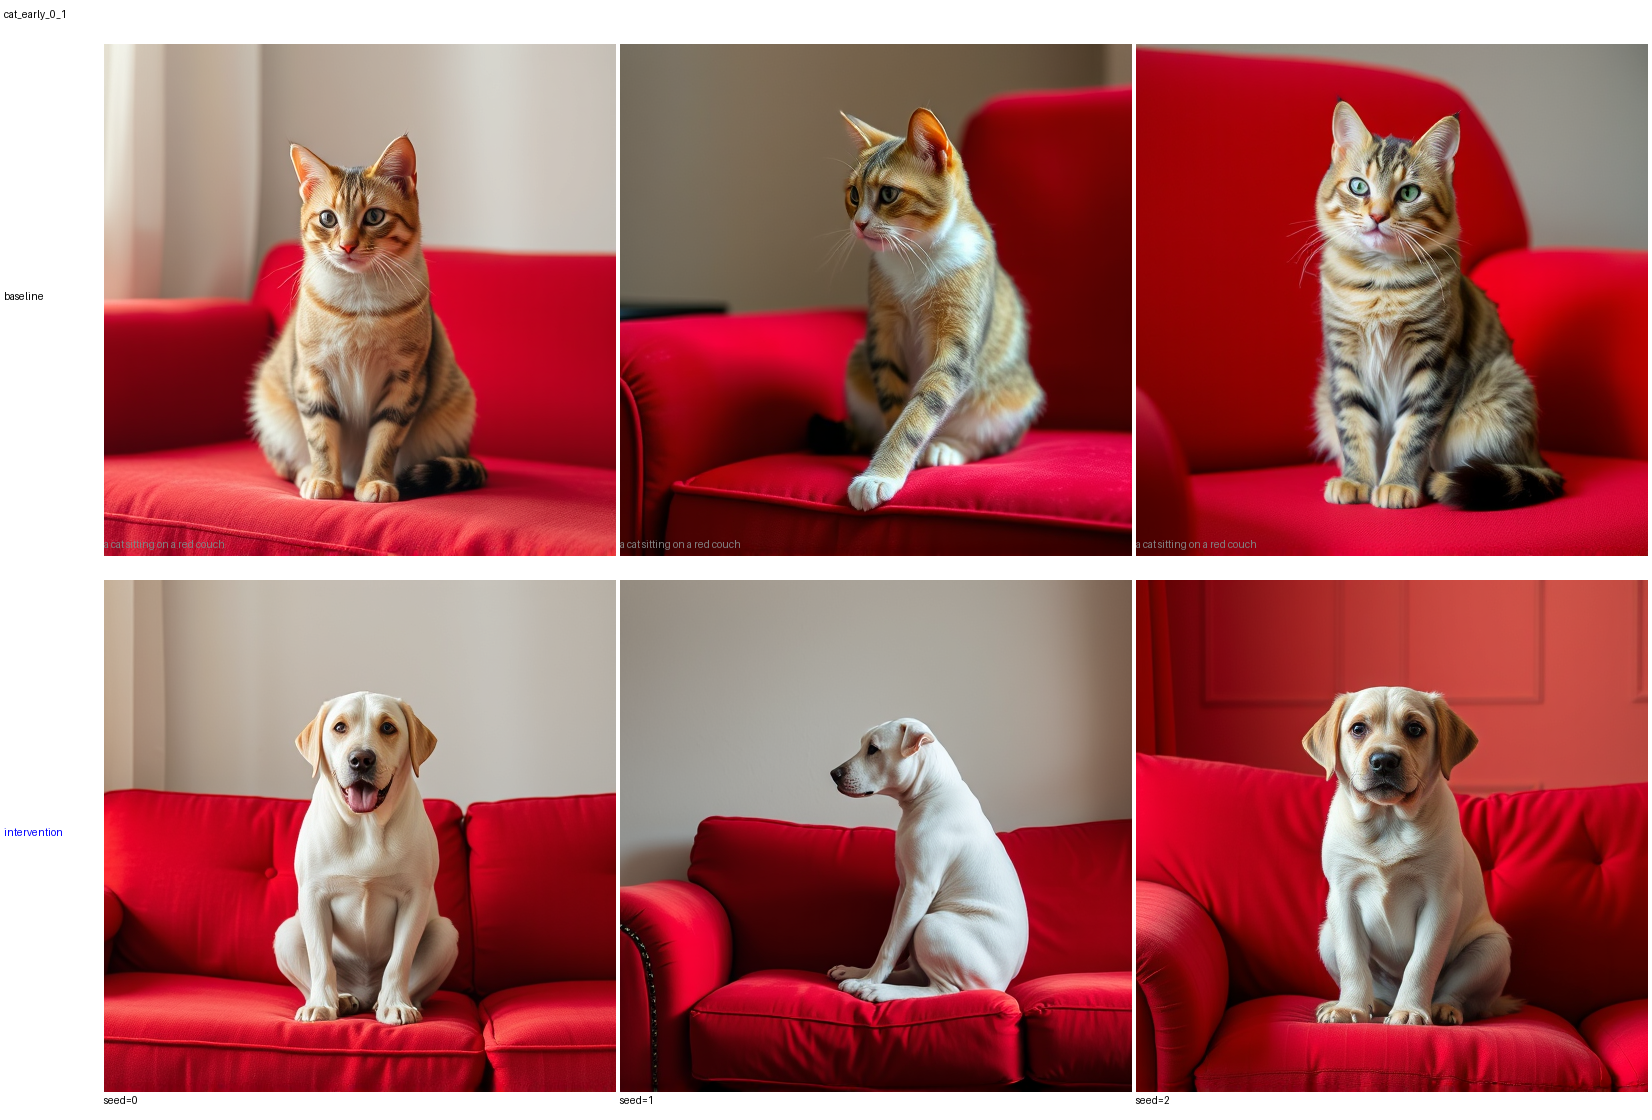

cat_late_2_3: 3 seeds | 'a cat sitting on a red couch'
    seed 0 (1/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

    seed 1 (2/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

    seed 2 (3/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

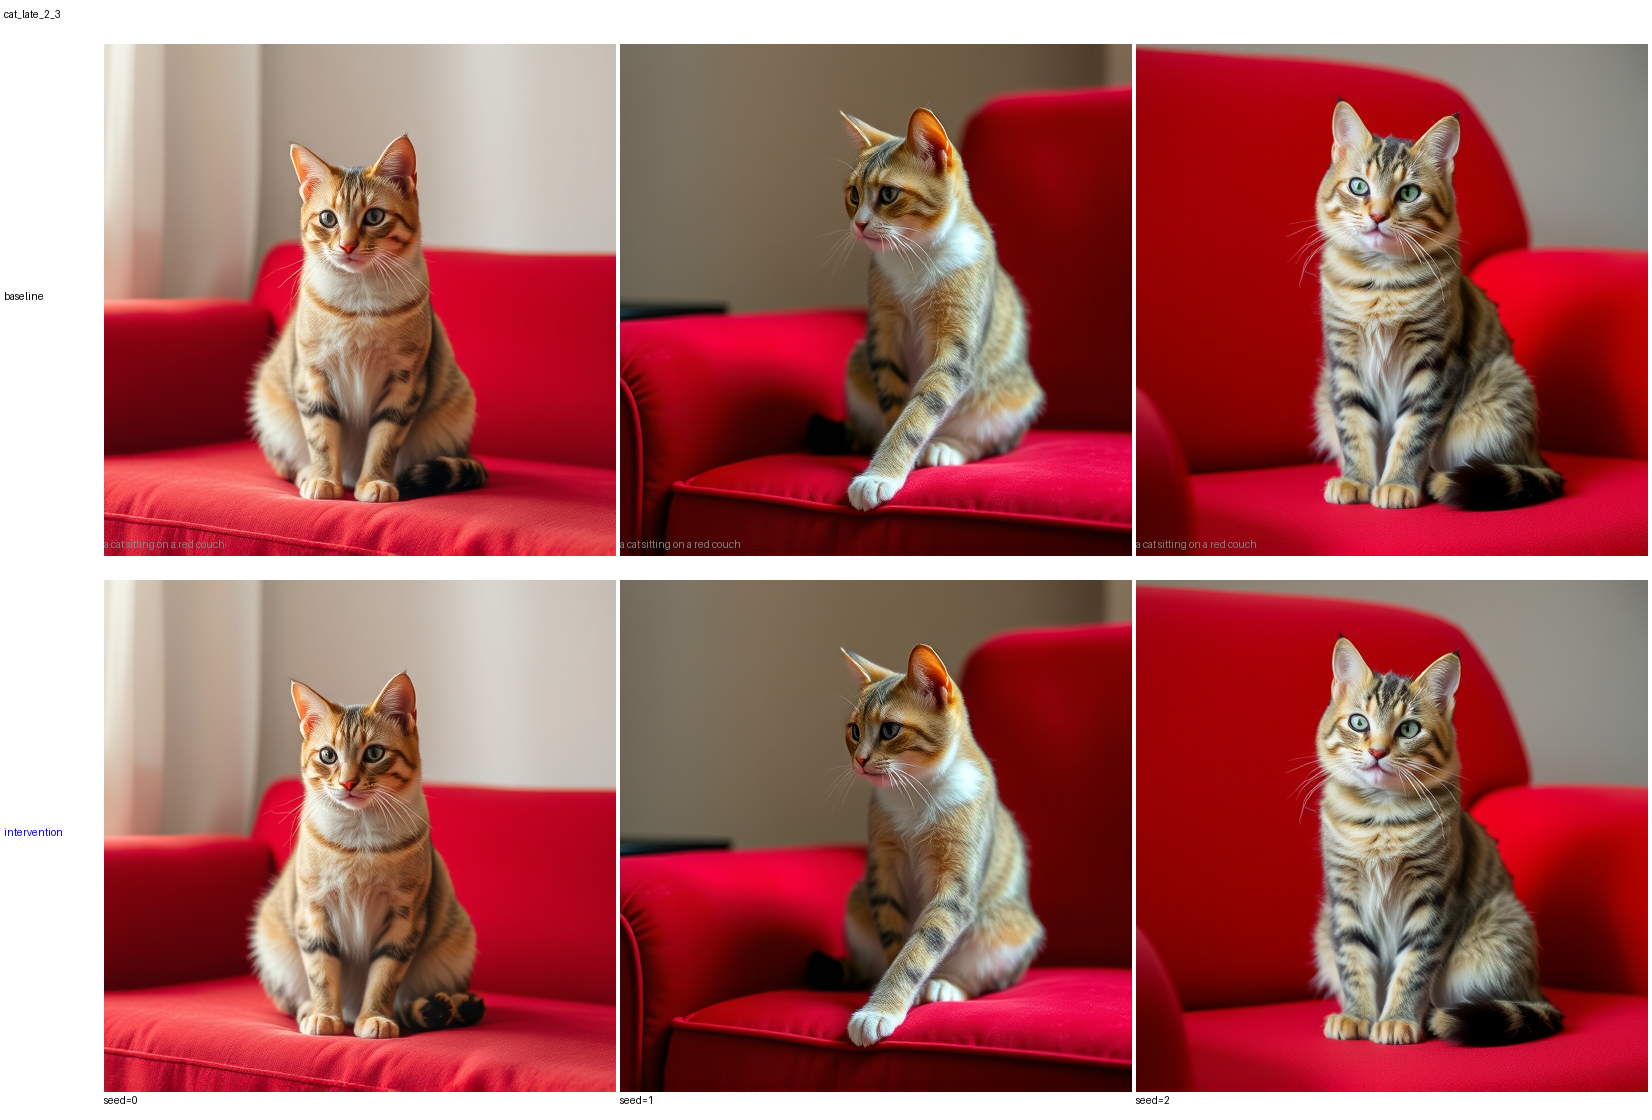

[{'seed': 0,
  'prompt': 'a cat sitting on a red couch',
  'config_name': 'cat_early_0_1',
  'baseline': <PIL.Image.Image image mode=RGB size=512x512>,
  'intervention': <PIL.Image.Image image mode=RGB size=512x512>},
 {'seed': 1,
  'prompt': 'a cat sitting on a red couch',
  'config_name': 'cat_early_0_1',
  'baseline': <PIL.Image.Image image mode=RGB size=512x512>,
  'intervention': <PIL.Image.Image image mode=RGB size=512x512>},
 {'seed': 2,
  'prompt': 'a cat sitting on a red couch',
  'config_name': 'cat_early_0_1',
  'baseline': <PIL.Image.Image image mode=RGB size=512x512>,
  'intervention': <PIL.Image.Image image mode=RGB size=512x512>},
 {'seed': 0,
  'prompt': 'a cat sitting on a red couch',
  'config_name': 'cat_late_2_3',
  'baseline': <PIL.Image.Image image mode=RGB size=512x512>,
  'intervention': <PIL.Image.Image image mode=RGB size=512x512>},
 {'seed': 1,
  'prompt': 'a cat sitting on a red couch',
  'config_name': 'cat_late_2_3',
  'baseline': <PIL.Image.Image image mo

In [5]:
from transcoder_circuits.interventions import (
    InterventionRunner, InterventionConfig, FeatureIntervention,
)

runner = InterventionRunner(pipe, transcoders)
SEEDS = [0, 1, 2]

CAT_TXT = [(11, "txt", 15358), (11, "txt", 23435), (11, "txt", 33762), (10, "txt", 8060), (9, "txt", 47011)]
PROMPT_CAUSAL = "a cat sitting on a red couch"

def suppress(features, steps):
    return [FeatureIntervention(layer=l, stream=s, feat_idx=i, mode="amplify", scale=-30.0, steps=set(steps)) for (l, s, i) in features]

configs = [
    InterventionConfig("cat_early_0_1", PROMPT_CAUSAL, SEEDS, interventions=suppress(CAT_TXT, [0, 1])),
    InterventionConfig("cat_late_2_3",  PROMPT_CAUSAL, SEEDS, interventions=suppress(CAT_TXT, [2, 3])),
]
runner.run_experiment(configs, output_dir="temporal_causal_out")